In [1]:
import sys, os, argparse
sys.path.append(os.path.abspath(".."))

import numpy as np
import torch
import torch.multiprocessing as mp
from tqdm import tqdm
import itertools
import re
import matplotlib.pyplot as plt

import grid_pkg
import controller_pkg
import controller_utils
import dQPTH
import evals

torch.set_default_dtype(torch.double)
torch.set_printoptions(threshold=10000)
NUMPY_SEED = 0
forecast_seed = 0
np.random.seed(NUMPY_SEED)
torch.manual_seed(forecast_seed)

skipping pardiso


### Process OURS

In [3]:
param_grid = {
    "forecast_seed":    [i for i in range(5)],
    "noise_mag":        [2.0, 2.4, 2.45, 2.5, 3.0, 3.5, 4.0],
    "offset":           [0, 60, 120, 180],
    "epochs":           [120],
    "radius":           [0.2],
    "lr":               [1e-3],
    "optimizer_type":   ["clipped_gd"],
    "lr_schedule":      ["plateau"],
    "patience":         [5],
    "batch_size":       [2],
    "max_grad_norm":    [3e4]
}
FOLDER_PATH = "ours"

our_losses_dict = dict()

noise_mag_vals = param_grid["noise_mag"]
offset_vals = param_grid["offset"]
nonzero_test_skew_mags = [10, 20, 30, 40]
test_seeds = [0, 1, 2]
forecast_seeds = param_grid["forecast_seed"]
epochs = param_grid["epochs"][0]
lr = param_grid["lr"][0]
radius = param_grid["radius"][0]
optimizer_type = param_grid["optimizer_type"][0]
lr_schedule = param_grid["lr_schedule"][0]
patience = param_grid["patience"][0]
batch_size = param_grid["batch_size"][0]
max_grad_norm = param_grid["max_grad_norm"][0]
default_lr_decay = 20

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0
existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for noise_mag, offset, forecast_seed in itertools.product(noise_mag_vals, offset_vals, forecast_seeds):
    done += 1
    filename = f"ours_noise_mag{noise_mag}_offset{offset}_epochs{epochs}_lr{lr}_forecast_seed{forecast_seed}_radius{radius}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}.pt"

    if filename not in existing_files:
        missing_combos.append((noise_mag, offset, forecast_seed))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
        # process the ones with nonzero test skew mag
        for test_seed, test_skew_mag in itertools.product(test_seeds, nonzero_test_skew_mags):
            our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)] = ckpt[(test_skew_mag, test_seed)][:,0]
        # process the ones with zero test skew mag
        our_losses_dict[(noise_mag,offset,0,forecast_seed)] = ckpt[(0)][:,0]

print(f"missing: {missing_combos}")

Total files found in directory: 140
missing: []


### Process PROXY

In [4]:
param_grid = {
    "forecast_seed":    [i for i in range(5)],
    "noise_mag":        [2.0, 2.4, 2.45, 2.5, 3.0, 3.5, 4.0],
    "offset":           [0, 60, 120, 180],
    "epochs":           [120],
    "radius":           [0.2],
    "lr":               [1e-3],
    "optimizer_type":   ["clipped_gd"],
    "lr_schedule":      ["plateau"],
    "patience":         [5],
    "batch_size":       [2],
    "max_grad_norm":    [3e4]
}
FOLDER_PATH = "proxy"

proxy_losses_dict = dict()

noise_mag_vals = param_grid["noise_mag"]
offset_vals = param_grid["offset"]
nonzero_test_skew_mags = [10, 20, 30, 40]
test_seeds = [0, 1, 2]
forecast_seeds = param_grid["forecast_seed"]
epochs = param_grid["epochs"][0]
lr = param_grid["lr"][0]
radius = param_grid["radius"][0]
optimizer_type = param_grid["optimizer_type"][0]
lr_schedule = param_grid["lr_schedule"][0]
patience = param_grid["patience"][0]
batch_size = param_grid["batch_size"][0]
max_grad_norm = param_grid["max_grad_norm"][0]
default_lr_decay = 20

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0
existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for noise_mag, offset, forecast_seed in itertools.product(noise_mag_vals, offset_vals, forecast_seeds):
    done += 1
    filename = f"proxy_noise_mag{noise_mag}_offset{offset}_epochs{epochs}_lr{lr}_forecast_seed{forecast_seed}_radius{radius}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}.pt"

    if filename not in existing_files:
        missing_combos.append((noise_mag, offset, forecast_seed))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
        # process the ones with nonzero test skew mag
        for test_seed, test_skew_mag in itertools.product(test_seeds, nonzero_test_skew_mags):
            proxy_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)] = ckpt[(test_skew_mag, test_seed)][:,0]
        # process the ones with zero test skew mag
        proxy_losses_dict[(noise_mag,offset,0,forecast_seed)] = ckpt[(0)][:,0]

print(f"missing: {missing_combos}")

Total files found in directory: 140
missing: []


### Process OPT

In [5]:
param_grid = {
    "noise_mag":        [2.0, 2.4, 2.45, 2.5, 3.0, 3.5, 4.0],
    "offset":           [i * 60 for i in range(4)],
    "test_skew_mag":    [0, 10, 20, 30, 40],
    "radius":           [0.2]
}
FOLDER_PATH = "opt"

opt_losses_dict = dict()

noise_mag_vals = param_grid["noise_mag"]
offset_vals = param_grid["offset"]
test_skew_mags = param_grid["test_skew_mag"]
radius = param_grid["radius"][0]
test_seeds = [0, 1, 2]

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0

existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for noise_mag, offset, test_skew_mag in itertools.product(noise_mag_vals, offset_vals, test_skew_mags):
    if test_skew_mag == 0:
        filename = f"opt_noise_mag{noise_mag}_offset{offset}_radius{radius}.pt"
    else:
        filename = f"opt_noise_mag{noise_mag}_offset{offset}_test_skew_mag{test_skew_mag}_radius{radius}.pt"
    if filename not in existing_files:
        missing_combos.append((noise_mag, offset, test_skew_mag))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
        if test_skew_mag == 0:
            opt_losses_dict[(noise_mag,offset,test_skew_mag)] = ckpt[("optimal")][:,0]
        else:
            for test_seed in test_seeds:
                opt_losses_dict[(noise_mag,offset,test_skew_mag,test_seed)] = ckpt[(test_seed, "optimal")][:,0]

print(f"Missing: {missing_combos}")

Total files found in directory: 140
Missing: []


### Process DEC

In [6]:
param_grid = {
    "noise_mag":        [2.0, 2.4, 2.45, 2.5, 3.0, 3.5, 4.0],
    "offset":           [i * 60 for i in range(4)],
    "test_skew_mag":    [0, 10, 20, 30, 40],
    "radius":           [0.2]
}
FOLDER_PATH = "dec"

dec_losses_dict = dict()

noise_mag_vals = param_grid["noise_mag"]
offset_vals = param_grid["offset"]
test_skew_mags = param_grid["test_skew_mag"]
radius = param_grid["radius"][0]
test_seeds = [0, 1, 2]

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0

existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for noise_mag, offset, test_skew_mag in itertools.product(noise_mag_vals, offset_vals, test_skew_mags):
    if test_skew_mag == 0:
        filename = f"dec_noise_mag{noise_mag}_offset{offset}_radius{radius}.pt"
    else:
        filename = f"dec_noise_mag{noise_mag}_offset{offset}_test_skew_mag{test_skew_mag}_radius{radius}.pt"
    if filename not in existing_files:
        missing_combos.append((noise_mag, offset, test_skew_mag, forecast_seed))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
        if test_skew_mag == 0:
            dec_losses_dict[(noise_mag,offset,test_skew_mag)] = ckpt[("base")]
        else:
            for test_seed in test_seeds:
                dec_losses_dict[(noise_mag,offset,test_skew_mag,test_seed)] = ckpt[(test_seed, "base")][:,0]

print(missing_combos)

Total files found in directory: 140
[]


### plot results

In [7]:
test_skew_mags = [0, 10, 20, 30, 40]
prod = itertools.product(noise_mag_vals, offset_vals, test_skew_mags)
results = dict()
num_forecast_seeds = len(forecast_seeds)
num_test_seeds = len(test_seeds)
for noise_mag, offset, test_skew_mag in prod:

    if test_skew_mag == 0:
        our_losses_means = torch.zeros(num_forecast_seeds)
        our_losses_raw = torch.zeros(num_forecast_seeds, 10)
        our_gap_raw = torch.zeros(num_forecast_seeds, 10)
        for forecast_seed in forecast_seeds:
            our_losses = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed)]
            opt_losses = opt_losses_dict[(noise_mag,offset,test_skew_mag)]
            dec_losses = dec_losses_dict[(noise_mag,offset,test_skew_mag)]
            our_losses_means[forecast_seed] = torch.mean(our_losses)
            our_losses_raw[forecast_seed] = our_losses
            our_gap_raw[forecast_seed] = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed)] / opt_losses
    else:
        our_losses_means = torch.zeros(num_forecast_seeds, num_test_seeds)
        our_losses_raw = torch.zeros(num_forecast_seeds, num_test_seeds, 10)
        our_gap_raw = torch.zeros(num_forecast_seeds, num_test_seeds, 10)
        for forecast_seed, test_seed in itertools.product(forecast_seeds, test_seeds):
            our_losses = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)]
            opt_losses = opt_losses_dict[(noise_mag,offset,test_skew_mag,test_seed)]
            dec_losses = dec_losses_dict[(noise_mag,offset,test_skew_mag,test_seed)]
            our_losses_means[forecast_seed,test_seed] = torch.mean(our_losses)
            our_losses_raw[forecast_seed,test_seed] = our_losses
            our_gap_raw[forecast_seed,test_seed] = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)] / opt_losses

    mean_ours = torch.mean(our_losses_raw.flatten())
    std_ours = torch.std(our_losses_raw.flatten())
    mean_opt = torch.mean(opt_losses)
    mean_dec = torch.mean(dec_losses)

    mean_our_gap = torch.mean(our_gap_raw.flatten())
    std_our_gap = torch.std(our_gap_raw.flatten())
    max_our_gap = torch.max(our_gap_raw.flatten())

    subresults = dict()
    # subresults["our_losses_raw"] = our_losses_raw
    subresults["opt_losses"] = opt_losses
    subresults["dec_losses"] = dec_losses
    subresults["mean_ours"] = mean_ours
    subresults["std_ours"] = std_ours
    subresults["mean_opt"] = mean_opt
    # subresults["std_opt"] = std_opt
    subresults["mean_dec"] = mean_dec
    # subresults["std_dec"] = std_dec
    # subresults["our_gap"] = our_gap
    subresults["mean_our_gap"] = mean_our_gap
    subresults["std_our_gap"] = std_our_gap
    subresults["max_our_gap"] = max_our_gap

    results[(noise_mag,offset,test_skew_mag)] = subresults


In [8]:
test_skew_mags = [0, 10, 20, 30, 40]
prod = itertools.product(noise_mag_vals, offset_vals, test_skew_mags)
results = dict()
num_forecast_seeds = len(forecast_seeds)
num_test_seeds = len(test_seeds)
for noise_mag, offset, test_skew_mag in prod:

    if test_skew_mag == 0:
        our_losses_means = torch.zeros(num_forecast_seeds)
        our_losses_raw = torch.zeros(num_forecast_seeds, 10)
        our_gap_raw = torch.zeros(num_forecast_seeds, 10)
        for forecast_seed in forecast_seeds:
            our_losses = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed)]
            opt_losses = opt_losses_dict[(noise_mag,offset,test_skew_mag)]
            dec_losses = dec_losses_dict[(noise_mag,offset,test_skew_mag)]
            our_losses_means[forecast_seed] = torch.mean(our_losses)
            our_losses_raw[forecast_seed] = our_losses
            our_gap_raw[forecast_seed] = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed)] / opt_losses
    else:
        our_losses_means = torch.zeros(num_forecast_seeds, num_test_seeds)
        our_losses_raw = torch.zeros(num_forecast_seeds, num_test_seeds, 10)
        our_gap_raw = torch.zeros(num_forecast_seeds, num_test_seeds, 10)
        for forecast_seed, test_seed in itertools.product(forecast_seeds, test_seeds):
            our_losses = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)]
            opt_losses = opt_losses_dict[(noise_mag,offset,test_skew_mag,test_seed)]
            dec_losses = dec_losses_dict[(noise_mag,offset,test_skew_mag,test_seed)]
            our_losses_means[forecast_seed,test_seed] = torch.mean(our_losses)
            our_losses_raw[forecast_seed,test_seed] = our_losses
            our_gap_raw[forecast_seed,test_seed] = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)] / opt_losses

    mean_ours = torch.mean(our_losses_raw.flatten())
    std_ours = torch.std(our_losses_raw.flatten())
    mean_opt = torch.mean(opt_losses)
    mean_dec = torch.mean(dec_losses)

    mean_our_gap = torch.mean(our_gap_raw.flatten())
    std_our_gap = torch.std(our_gap_raw.flatten())
    max_our_gap = torch.max(our_gap_raw.flatten())

    subresults = dict()
    # subresults["our_losses_raw"] = our_losses_raw
    subresults["opt_losses"] = opt_losses
    subresults["dec_losses"] = dec_losses
    subresults["mean_ours"] = mean_ours
    subresults["std_ours"] = std_ours
    subresults["mean_opt"] = mean_opt
    # subresults["std_opt"] = std_opt
    subresults["mean_dec"] = mean_dec
    # subresults["std_dec"] = std_dec
    # subresults["our_gap"] = our_gap
    subresults["mean_our_gap"] = mean_our_gap
    subresults["std_our_gap"] = std_our_gap
    subresults["max_our_gap"] = max_our_gap

    results[(noise_mag,offset,test_skew_mag)] = subresults


/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/3276799639.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/3276799639.py:48: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


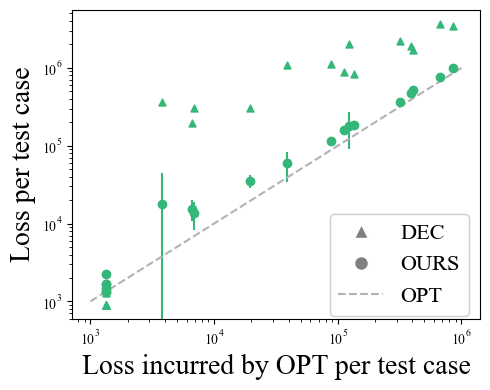

In [9]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(5,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5


for test_skew_mag in [0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt > 0:
        
            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")

axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=20)
axs.set_ylabel("Loss per test case", fontsize=20)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}', markersize=10) for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, loc='lower right', bbox_to_anchor=(0.97, 0.17), fontsize=16)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
# fig.legend(handles=shift_handles, title=r"Shift $\enoise_magilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("figures/Experiment results 1.png", dpi=500, bbox_inches='tight')

<>:85: SyntaxWarning: invalid escape sequence '\p'
<>:85: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/1814721115.py:85: SyntaxWarning: invalid escape sequence '\p'
  fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/1814721115.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


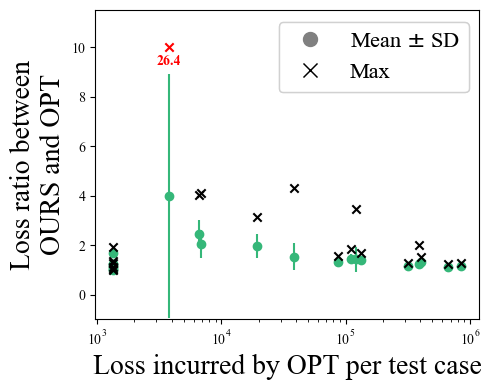

In [10]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Linux Libertine'] + plt.rcParams['font.serif']

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This manoise_mag 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(5,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 10

min_opt = 1.4e3
max_opt = 2.2e4

directions = [1, 0, 0, 1, 1]
idx = 0
for test_skew_mag in [0]:
    all_mean_opt = []
    all_mean_our_gap = []
    all_std_our_gap = []
    normal_max_x = []
    normal_max_y = []
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag, offset, test_skew_mag)]

        # Extract values (using .item() for clean floats)
        m_opt = data["mean_opt"].item()
        m_gap = data["mean_our_gap"].item()
        s_gap = data["std_our_gap"].item()
        mx_gap = data["max_our_gap"].item()

        if True:

            # 1. Store main data for the big batch plot
            all_mean_opt.append(m_opt)
            all_mean_our_gap.append(m_gap)
            all_std_our_gap.append(s_gap)

            # 2. Sort the "Max" points: List vs. Immediate Annotation
            if mx_gap < Y_LIMIT:
                # If it fits, save it to the list to scatter later
                normal_max_x.append(m_opt)
                normal_max_y.append(mx_gap)
            else:
                # If it's an outlier, plot the annotation immediately
                # (Annotations can't be batched easily)
                # axs.annotate('', xy=(m_opt, Y_LIMIT), xytext=(m_opt, Y_LIMIT - 1.0),
                #              arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2))
                direction = directions[idx]
                idx += 1
                if direction == 0:
                    if idx == 2: 
                        axs.text(m_opt * 0.997, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                    else:
                        axs.text(m_opt * 1.003, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                else:
                    axs.text(m_opt, Y_LIMIT - 0.3, f'{mx_gap:.1f}',
                            color='red', fontweight='bold', ha='center', va='top',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                axs.scatter(m_opt, Y_LIMIT, color='red', marker='x')

    # 3. Plot all means and error bars at once
    axs.errorbar(all_mean_opt, all_mean_our_gap, all_std_our_gap,
                fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)

    # 4. Plot all "normal" max points at once
    axs.scatter(normal_max_x, normal_max_y, c="black", marker="x",label="Max", zorder=2)

# 5. Lock the Y-axis
axs.set_ylim(-1, Y_LIMIT + 1.5)
axs.set_xscale("log")
h_mean = Line2D([0], [0], marker='o', color='w', 
                markerfacecolor='gray', markeredgecolor='gray', 
                linestyle='none', markersize=10, label=r"Mean $\pm$ SD")

# 2. "Max": 'X' with black edge (this was the invisible one)
h_max  = Line2D([0], [0], marker='x', color='w', 
                markeredgecolor='black',  # <--- THIS FIXES THE INVISIBLE X
                linestyle='none', markersize=10, label="Max")
method_handles = [h_mean, h_max]
leg1 = fig.legend(handles=method_handles, loc='upper right', bbox_to_anchor=(0.97, 0.96), fontsize=16)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%', markersize=10) for k, c in test_skew_mag_colors.items()]
# fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# Optional: Add legend
# axs.legend(loc='upper right')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=20)
axs.set_ylabel("Loss ratio between\nOURS and OPT", fontsize=20)
fig.tight_layout()
fig.savefig("figures/Experiment results 2.png", dpi=500, bbox_inches='tight')

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/1531051948.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/1531051948.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


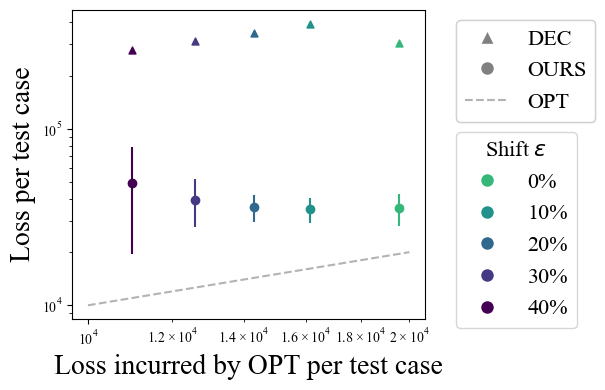

In [11]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(4.5,4))
smallest = 1000
identity = torch.linspace(1e4,2e4,101)

Y_LIMIT = 9.5

for test_skew_mag in [40, 30, 20, 10, 0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt > 1e4 and mean_opt < 2e4:
        
            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")
    
axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=20)
axs.set_ylabel("Loss per test case", fontsize=20)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}', markersize=10) for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, loc='upper left', bbox_to_anchor=(1, 0.965), fontsize=16)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%', markersize=10) for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.685), fontsize=16, title_fontsize=16)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("figures/Experiment results 3.png", dpi=500, bbox_inches='tight')

In [12]:
test_skew_mags = [0]
mean_dict = dict()
for tsm in test_skew_mags:
    mean_dict[tsm] = list()


for noise_mag, offset, test_skew_mag, forecast_seed in itertools.product(noise_mag_vals, offset_vals, test_skew_mags, forecast_seeds):
    our_losses = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed)]
    surrogate_losses = proxy_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed)]
    mean_dict[test_skew_mag].append(torch.mean(surrogate_losses / our_losses))

test_skew_mags = [10, 20, 30, 40]
for tsm in test_skew_mags:
    mean_dict[tsm] = list()

for noise_mag, offset, test_skew_mag, forecast_seed, test_seed in itertools.product(noise_mag_vals, offset_vals, test_skew_mags, forecast_seeds, test_seeds):
    our_losses = our_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)]
    surrogate_losses = proxy_losses_dict[(noise_mag,offset,test_skew_mag,forecast_seed,test_seed)]
    mean_dict[test_skew_mag].append(torch.mean(surrogate_losses / our_losses))

<>:19: SyntaxWarning: invalid escape sequence '\%'
<>:19: SyntaxWarning: invalid escape sequence '\%'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/3092002319.py:19: SyntaxWarning: invalid escape sequence '\%'
  axs[row,col].text(1.065, 200, f'{pct_over:.1f}\%\nover 1.05',


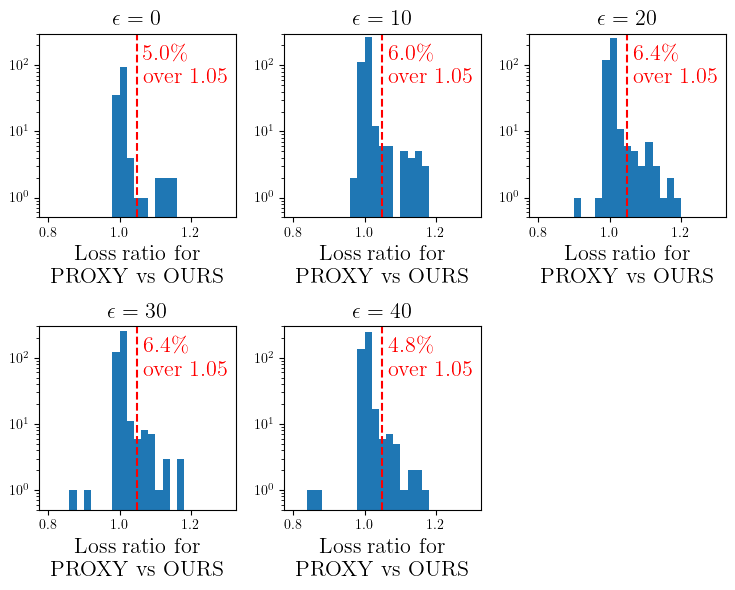

In [13]:
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

rows = 2
cols = 3
fig, axs = plt.subplots(rows, cols, figsize=(7.5,6))
bins = [0.8 + 0.02 * i for i in range(0,26)]
test_skew_mags = [0, 10, 20, 30, 40]
for i in range(len(test_skew_mags)):
    row = i // 3
    col = i % 3
    data = mean_dict[test_skew_mags[i]]
    pct_over = 100 * sum(v > 1.05 for v in data) / len(data)
    axs[row,col].hist(data, bins=bins)
    axs[row,col].axvline(x=1.05, color='red', linestyle='--', linewidth=1.5)
    axs[row,col].text(1.065, 200, f'{pct_over:.1f}\%\nover 1.05',
                      color='red', fontsize=16, va='top', ha='left')
    axs[row,col].set_title(rf"$ \epsilon={test_skew_mags[i]}$", fontsize=16)
    axs[row,col].set_yscale('log')
    axs[row,col].set_xlabel("Loss ratio for\nPROXY vs OURS", fontsize=16)
    axs[row,col].set_ylim(bottom=0.5, top=300)
axs[1,2].set_visible(False)
fig.tight_layout()
plt.savefig("figures/Experiment results 4.png", dpi=300)

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/2290799229.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/2290799229.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


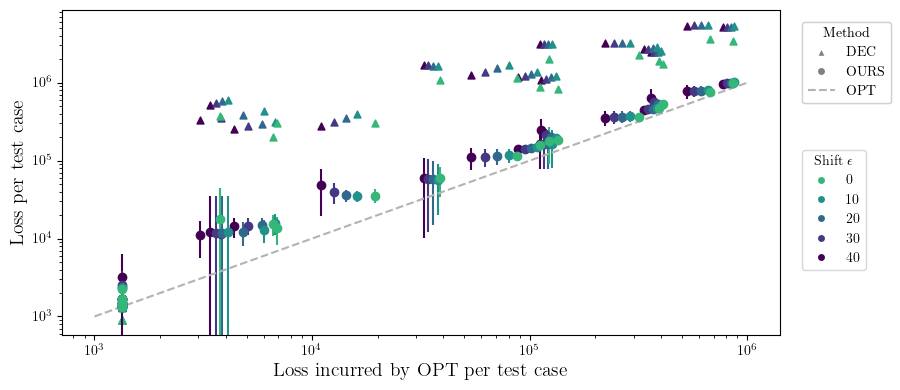

In [14]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

for test_skew_mag in [40, 30, 20, 10, 0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt > 0:
        
            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")

axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss per test case", fontsize=14)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}') for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.95), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("figures/Experiment results 1 appendix 1", dpi=500, bbox_inches='tight')

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/2448324288.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/2448324288.py:50: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


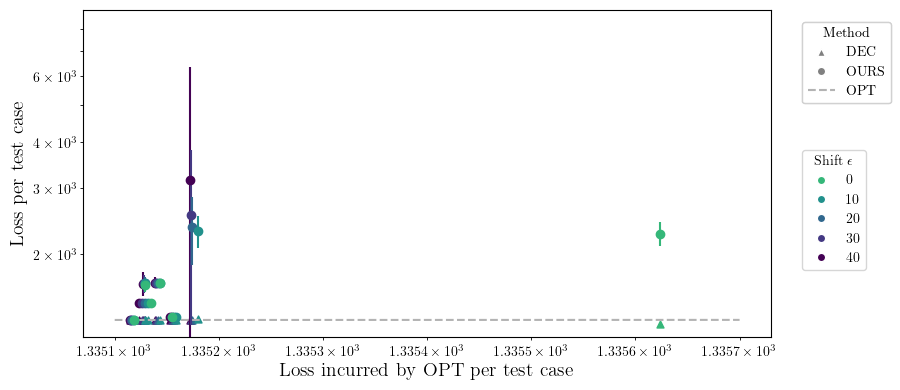

In [15]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

identity = torch.linspace(1.3351e3,1.3357e3,101)
axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))

for test_skew_mag in [40, 30, 20, 10, 0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt <1400:

            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")

handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_ylim(1.2e3)
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss per test case", fontsize=14)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
                     linestyle='none', label=f'{k}') for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.95), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("figures/Experiment results 1 appendix 2", dpi=500, bbox_inches='tight')

<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/4226525784.py:91: SyntaxWarning: invalid escape sequence '\p'
  fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/4226525784.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


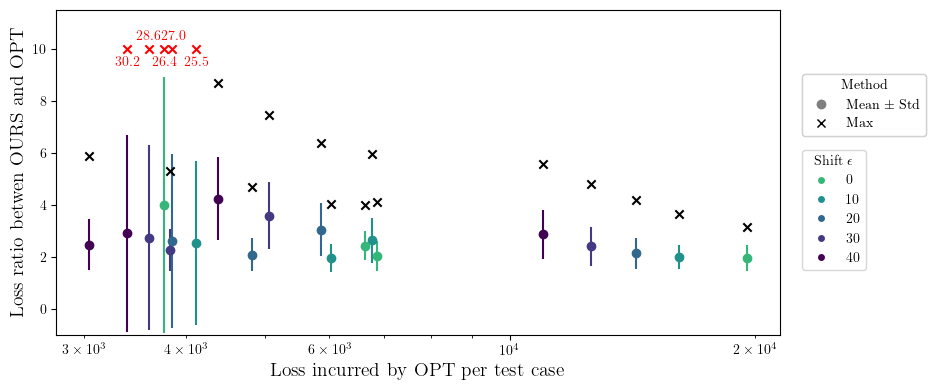

In [16]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Linux Libertine'] + plt.rcParams['font.serif']

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

# Initialize lists


# Define your cutoff
Y_LIMIT = 10

min_opt = 1.4e3
max_opt = 2.2e4

directions = [1, 0, 0, 1, 1]
idx = 0
for test_skew_mag in [40,30,20,10,0]:
    all_mean_opt = []
    all_mean_our_gap = []
    all_std_our_gap = []
    normal_max_x = []
    normal_max_y = []
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag, offset, test_skew_mag)]

        # Extract values (using .item() for clean floats)
        m_opt = data["mean_opt"].item()
        m_gap = data["mean_our_gap"].item()
        s_gap = data["std_our_gap"].item()
        mx_gap = data["max_our_gap"].item()

        if m_opt > min_opt and m_opt < max_opt:

            # 1. Store main data for the big batch plot
            all_mean_opt.append(m_opt)
            all_mean_our_gap.append(m_gap)
            all_std_our_gap.append(s_gap)

            # 2. Sort the "Max" points: List vs. Immediate Annotation
            if mx_gap < Y_LIMIT:
                # If it fits, save it to the list to scatter later
                normal_max_x.append(m_opt)
                normal_max_y.append(mx_gap)
            else:
                # If it's an outlier, plot the annotation immediately
                # (Annotations can't be batched easily)
                # axs.annotate('', xy=(m_opt, Y_LIMIT), xytext=(m_opt, Y_LIMIT - 1.0),
                #              arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2))
                direction = directions[idx]
                idx += 1
                if direction == 0:
                    if idx == 2: 
                        axs.text(m_opt * 0.997, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                    else:
                        axs.text(m_opt * 1.003, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                else:
                    axs.text(m_opt, Y_LIMIT - 0.3, f'{mx_gap:.1f}',
                            color='red', fontweight='bold', ha='center', va='top',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                axs.scatter(m_opt, Y_LIMIT, color='red', marker='x')

    # 3. Plot all means and error bars at once
    axs.errorbar(all_mean_opt, all_mean_our_gap, all_std_our_gap,
                fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)

    # 4. Plot all "normal" max points at once
    axs.scatter(normal_max_x, normal_max_y, c="black", marker="x",label="Max", zorder=2)

# 5. Lock the Y-axis
axs.set_ylim(-1, Y_LIMIT + 1.5)
axs.set_xscale("log")
h_mean = Line2D([0], [0], marker='o', color='w', 
                markerfacecolor='gray', markeredgecolor='gray', 
                linestyle='none', label=r"Mean $\pm$ Std")

# 2. "Max": 'X' with black edge (this was the invisible one)
h_max  = Line2D([0], [0], marker='x', color='w', 
                markeredgecolor='black',  # <--- THIS FIXES THE INVISIBLE X
                linestyle='none', label="Max")
method_handles = [h_mean, h_max]
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.82), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# Optional: Add legend
# axs.legend(loc='upper right')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss ratio betwen OURS and OPT", fontsize=14)
fig.tight_layout()
fig.savefig("figures/Experiment results 2 appendix 1.png", dpi=500, bbox_inches='tight')

<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/571454180.py:91: SyntaxWarning: invalid escape sequence '\p'
  fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_15683/571454180.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


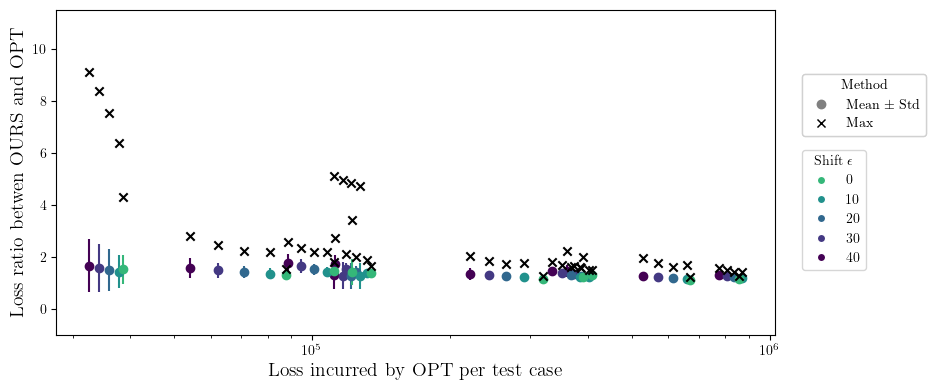

In [17]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Linux Libertine'] + plt.rcParams['font.serif']

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

# Initialize lists


# Define your cutoff
Y_LIMIT = 10

min_opt = 2.3e4
max_opt = 1e7

directions = [1, 0, 0, 1, 1]
idx = 0
for test_skew_mag in [40,30,20,10,0]:
    all_mean_opt = []
    all_mean_our_gap = []
    all_std_our_gap = []
    normal_max_x = []
    normal_max_y = []
    for noise_mag, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(noise_mag, offset, test_skew_mag)]

        # Extract values (using .item() for clean floats)
        m_opt = data["mean_opt"].item()
        m_gap = data["mean_our_gap"].item()
        s_gap = data["std_our_gap"].item()
        mx_gap = data["max_our_gap"].item()

        if m_opt > min_opt and m_opt < max_opt:

            # 1. Store main data for the big batch plot
            all_mean_opt.append(m_opt)
            all_mean_our_gap.append(m_gap)
            all_std_our_gap.append(s_gap)

            # 2. Sort the "Max" points: List vs. Immediate Annotation
            if mx_gap < Y_LIMIT:
                # If it fits, save it to the list to scatter later
                normal_max_x.append(m_opt)
                normal_max_y.append(mx_gap)
            else:
                # If it's an outlier, plot the annotation immediately
                # (Annotations can't be batched easily)
                # axs.annotate('', xy=(m_opt, Y_LIMIT), xytext=(m_opt, Y_LIMIT - 1.0),
                #              arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2))
                direction = directions[idx]
                idx += 1
                if direction == 0:
                    if idx == 2: 
                        axs.text(m_opt * 0.997, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                    else:
                        axs.text(m_opt * 1.003, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                else:
                    axs.text(m_opt, Y_LIMIT - 0.3, f'{mx_gap:.1f}',
                            color='red', fontweight='bold', ha='center', va='top',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                axs.scatter(m_opt, Y_LIMIT, color='red', marker='x')

    # 3. Plot all means and error bars at once
    axs.errorbar(all_mean_opt, all_mean_our_gap, all_std_our_gap,
                fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)

    # 4. Plot all "normal" max points at once
    axs.scatter(normal_max_x, normal_max_y, c="black", marker="x",label="Max", zorder=2)

# 5. Lock the Y-axis
axs.set_ylim(-1, Y_LIMIT + 1.5)
axs.set_xscale("log")
h_mean = Line2D([0], [0], marker='o', color='w', 
                markerfacecolor='gray', markeredgecolor='gray', 
                linestyle='none', label=r"Mean $\pm$ Std")

# 2. "Max": 'X' with black edge (this was the invisible one)
h_max  = Line2D([0], [0], marker='x', color='w', 
                markeredgecolor='black',  # <--- THIS FIXES THE INVISIBLE X
                linestyle='none', label="Max")
method_handles = [h_mean, h_max]
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.82), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# Optional: Add legend
# axs.legend(loc='upper right')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss ratio betwen OURS and OPT", fontsize=14)
fig.tight_layout()
fig.savefig("figures/Experiment results 2 appendix 2.png", dpi=500, bbox_inches='tight')